In [45]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import sys

sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")

import jax
jax.config.update("jax_enable_x64", True)

import jaxsp as jsp


import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

import pickle



In [46]:

m22 = 10
u = jsp.set_schroedinger_units(m22)
no_radius_bins = 1000
r_min = 20
r_max_enclosing_frac = 0.99

In [47]:
cache_dir = os.path.join("/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Tests/Testing_sim_methods", "precomputed_wf")
os.makedirs(cache_dir, exist_ok=True)
cache_suffix = f"m22_{float(m22):.6g}_rbins_{int(no_radius_bins)}"
r_j_r_fname = os.path.join(cache_dir, f"precomputed_R_j_r_{cache_suffix}.npz")
pkl_fname   = os.path.join(cache_dir, f"precomputed_objs_{cache_suffix}.pkl")

cache_params = {
    'm22': float(m22),
    'r_min': float(r_min),
    'r_max_enclosing_frac': float(r_max_enclosing_frac),
    'no_radius_bins': int(no_radius_bins),
}

def _cache_valid(data, expected):
    for k, v in expected.items():
        if k not in data.files:
            return False
        cached = data[k].item() if data[k].shape == () else data[k]
        if isinstance(v, float):
            if not np.isclose(cached, v):
                return False
        elif cached != v:
            return False
    return True

R_j_r = None
if os.path.isfile(r_j_r_fname) and os.path.isfile(pkl_fname):
    data = np.load(r_j_r_fname)
    if _cache_valid(data, cache_params):
        print(f"Loading precomputed R_j_r from {r_j_r_fname}...")
        R_j_r = data['R_j_r']
        rmin = data['rmin'].item()
        rmax = data['rmax'].item()
        with open(pkl_fname, 'rb') as f:
            objs = pickle.load(f)
        eigenstate_lib    = objs['eigenstate_lib']
        wavefunction_params = objs['wavefunction_params']
        eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0, None))

    else:
        print(f"Cached {r_j_r_fname} stale (parameter mismatch); recomputing.")

if R_j_r is None:

    cNFWtides_params = jnp.array([
    357964808.148399 * u.from_Msun,
    25.690207,
    0.407461,
    0.012670 * u.from_Kpc,
    1.857991 * u.from_Kpc,
    3.729259
    ])

    density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

    N = 512
    rmin = .1 * u.from_pc
    rmax = jsp.enclosing_radius(0.999, density_params)
    potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)

    eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

    N = 1024
    a = 1
    b = 10

    rmax = jsp.enclosing_radius(r_max_enclosing_frac, density_params)
    eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)


    rmin = r_min * u.from_pc

    tol = 1e-7
    wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)


    r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), no_radius_bins)
    R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)  # (Nr, Nj)

    np.savez(r_j_r_fname, R_j_r=np.array(R_j_r), rmin=rmin, rmax=rmax, **cache_params)
    with open(pkl_fname, 'wb') as f:
        pickle.dump({'eigenstate_lib': eigenstate_lib, 'wavefunction_params': wavefunction_params}, f)

aj_2 = wavefunction_params.aj_2
aj = np.sqrt(aj_2)

l = eigenstate_lib.radial_eigenmode_params.l
n = eigenstate_lib.radial_eigenmode_params.n

eigen_energies = eigenstate_lib.radial_eigenmode_params.E

Loading precomputed R_j_r from /home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Tests/Testing_sim_methods/precomputed_wf/precomputed_R_j_r_m22_10_rbins_1000.npz...


[4.51162989e-02 4.13398677e-02 1.75963893e-05 7.99112650e-06
 2.41118275e-02 1.22075012e-02 3.68034536e-02 2.41459201e-06
 6.78344233e-02 9.74191953e-05 1.84885063e-03 1.76410877e-02
 2.09828503e-02 6.16472704e-02 3.13123682e-04 3.21193261e-02
 1.28569002e-02 3.10272914e-05 8.84955757e-06 8.42426485e-02]


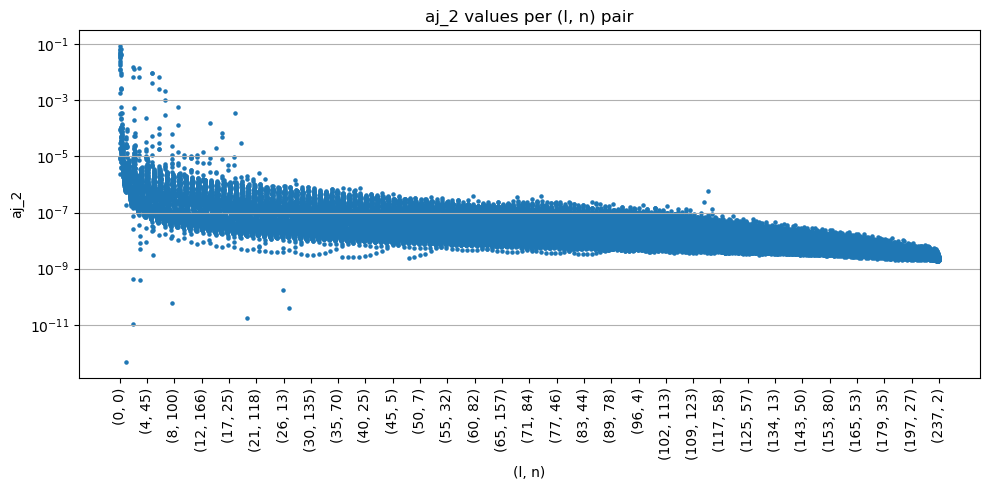

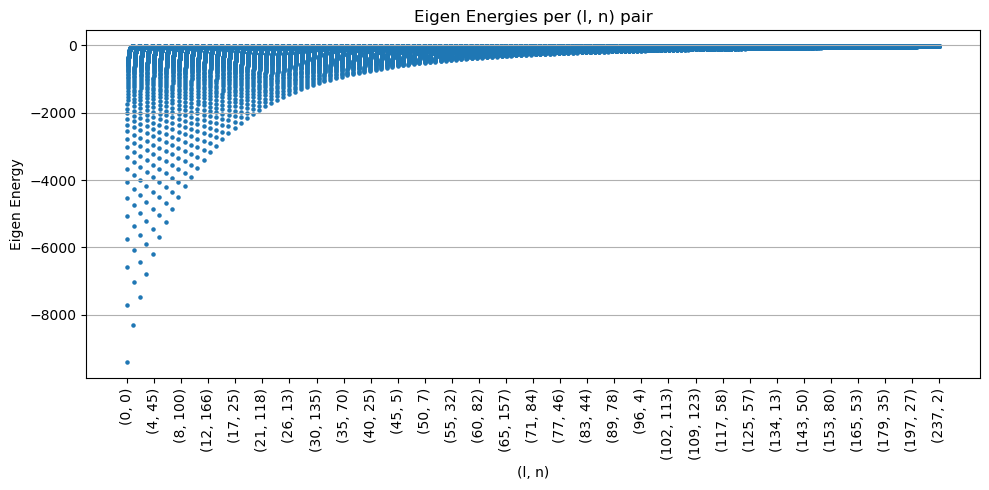

smallest time period [Gyr]: 0.0024506627265470414


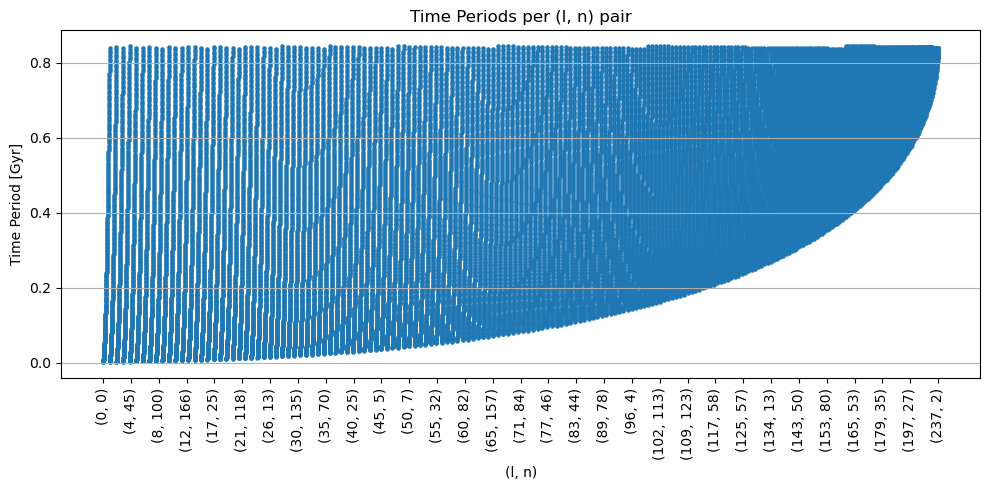

In [48]:

nl_labels = list(zip(l.tolist(), n.tolist()))


plt.figure(figsize=(10, 5))
plt.scatter(range(len(aj_2)), aj_2, s=5)
print(aj_2[0:20])

step = max(1, len(nl_labels) // 30)  # show ~30 labels
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('aj_2')
plt.title('aj_2 values per (l, n) pair')
plt.grid(axis='y')
plt.yscale('log')
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
plt.scatter(range(len(eigen_energies)), eigen_energies, s = 5)

plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Eigen Energy')
plt.title('Eigen Energies per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

time_periods = -(1 / eigen_energies) * u.to_Gyr

print('smallest time period [Gyr]:', time_periods.min())

plt.figure(figsize=(10, 5))
plt.scatter(range(len(time_periods)), time_periods, s = 5)

plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Time Period [Gyr]')
plt.title('Time Periods per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()




# Plotting beat frequencies

In [36]:
r_half = 0.19 * u.from_Kpc

sigma_kms  = 5.5
lam_dB_kpc = 19.15 / (m22 * sigma_kms)                    # ℏ/(m σ)
f_c        = (sigma_kms * 1.022) / (2 * np.pi * lam_dB_kpc)  # 1/τ_c   [cycles/Gyr]

f_orb      = 1 / (2 * np.pi * r_half / sigma_kms * u.from_kms) / u.to_Gyr # orbital frequency at r_half [cycles/Gyr]


print('orbital period [cycles Gyr]:', 1/f_orb)

R0 = r_half

R_j_r = eval_library(jnp.array([R0]), eigenstate_lib.radial_eigenmode_params)[0] 

# Per-eigenstate weight at R0, summed over m: (2l+1) |a_j|^2 |R_j(R0)|^2
# (Y_lm averaged over m at fixed l gives (2l+1)/(4π); the constant prefactor
#  doesn't affect the histogram shape, so drop it.)

w_j = np.array(aj_2 * (2*l + 1) * jnp.abs(R_j_r)**2)  # (Nj,)

#beat spectrum
E = np.array(eigen_energies)                               # code units
domega_code = np.abs(E[:, None] - E[None, :])              # (Nj, Nj)


f_beat = domega_code / (2 * np.pi * float(u.to_Gyr))   # (Nj, Nj)
weight = w_j[:, None] * w_j[None, :]                      # (Nj, Nj)

print('smallest beat period [Gyr]:', (1 / f_beat[f_beat > 0]).min())
print('largest beat period [Gyr]:', (1 / f_beat[f_beat > 0]).max())




orbital period [cycles Gyr]: 0.5217419334844965


smallest beat period [Gyr]: 0.12819067978810142
largest beat period [Gyr]: 12308033.37182474


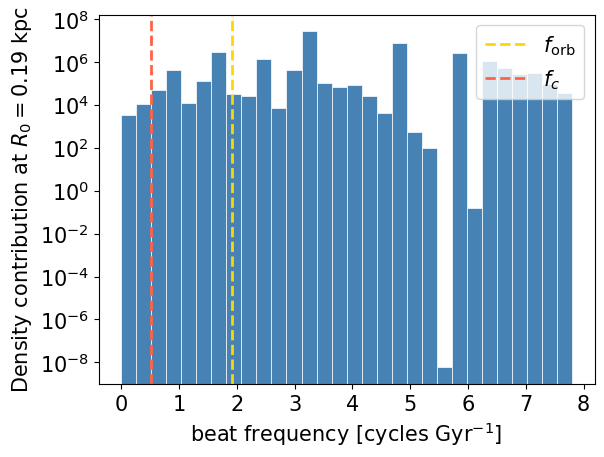

max weight beat period [Gyr]: 0.30590953767187434


In [37]:
mask = f_beat.ravel() > 0
plt.hist(f_beat.ravel()[mask],
         bins=30, weights=weight.ravel()[mask],
         log=True, alpha = 1, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(f_orb, ls='--', label=r'$f_{\rm orb}$', color='gold', linewidth=2)
plt.axvline(f_c, ls='--', label=r'$f_c$', color='tomato', linewidth=2)
plt.xlabel(r'beat frequency [cycles Gyr$^{-1}$]', fontsize=15)
plt.ylabel(f'Density contribution at $R_0 = {R0 * u.to_Kpc}$ kpc', fontsize=15)
plt.legend(fontsize=15, loc='upper right')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

max_weight_freq = np.where(weight.ravel()[mask] == weight.ravel()[mask].max(), f_beat.ravel()[mask], np.nan)
max_weight_period = 1 / max_weight_freq
print('max weight beat period [Gyr]:', max_weight_period[~np.isnan(max_weight_period)].min())

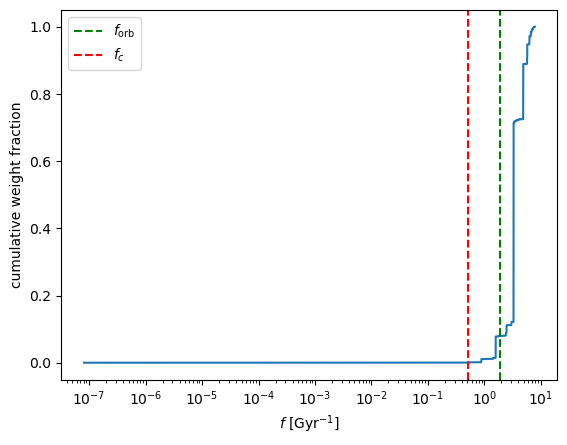

weight fraction with f > 3 f_orb: 0.027916712644914014


In [38]:
order = np.argsort(f_beat.ravel())
f_sorted = f_beat.ravel()[order]
w_sorted = weight.ravel()[order]
mask = f_sorted > 0
cum = np.cumsum(w_sorted[mask])
cum /= cum[-1]                     # fraction of total weight below f

plt.semilogx(f_sorted[mask], cum)
plt.axvline(f_orb, color='g', ls='--', label=r'$f_{\rm orb}$')
plt.axvline(f_c,   color='r', ls='--', label=r'$f_c$')
plt.xlabel(r'$f$ [Gyr$^{-1}$]'); plt.ylabel('cumulative weight fraction')
plt.legend(); plt.show()

# fraction of weight in the "impulsive" band (above a few × f_orb)
above_3forb = (f_sorted > 3*f_orb)
print('weight fraction with f > 3 f_orb:', w_sorted[above_3forb].sum() / w_sorted.sum())


## Heat map for $a_{nl}R_{nl}(r_*)a_{n'l'}R_{n'l'}(r_*)$


(28658,)
(1000, 28658)
(4, 28658)
10857
Plotting heatmap for r_star = 0.50 kpc...


Plotting heatmap for r_star = 1.00 kpc...
Plotting heatmap for r_star = 1.50 kpc...
Plotting heatmap for r_star = 2.00 kpc...


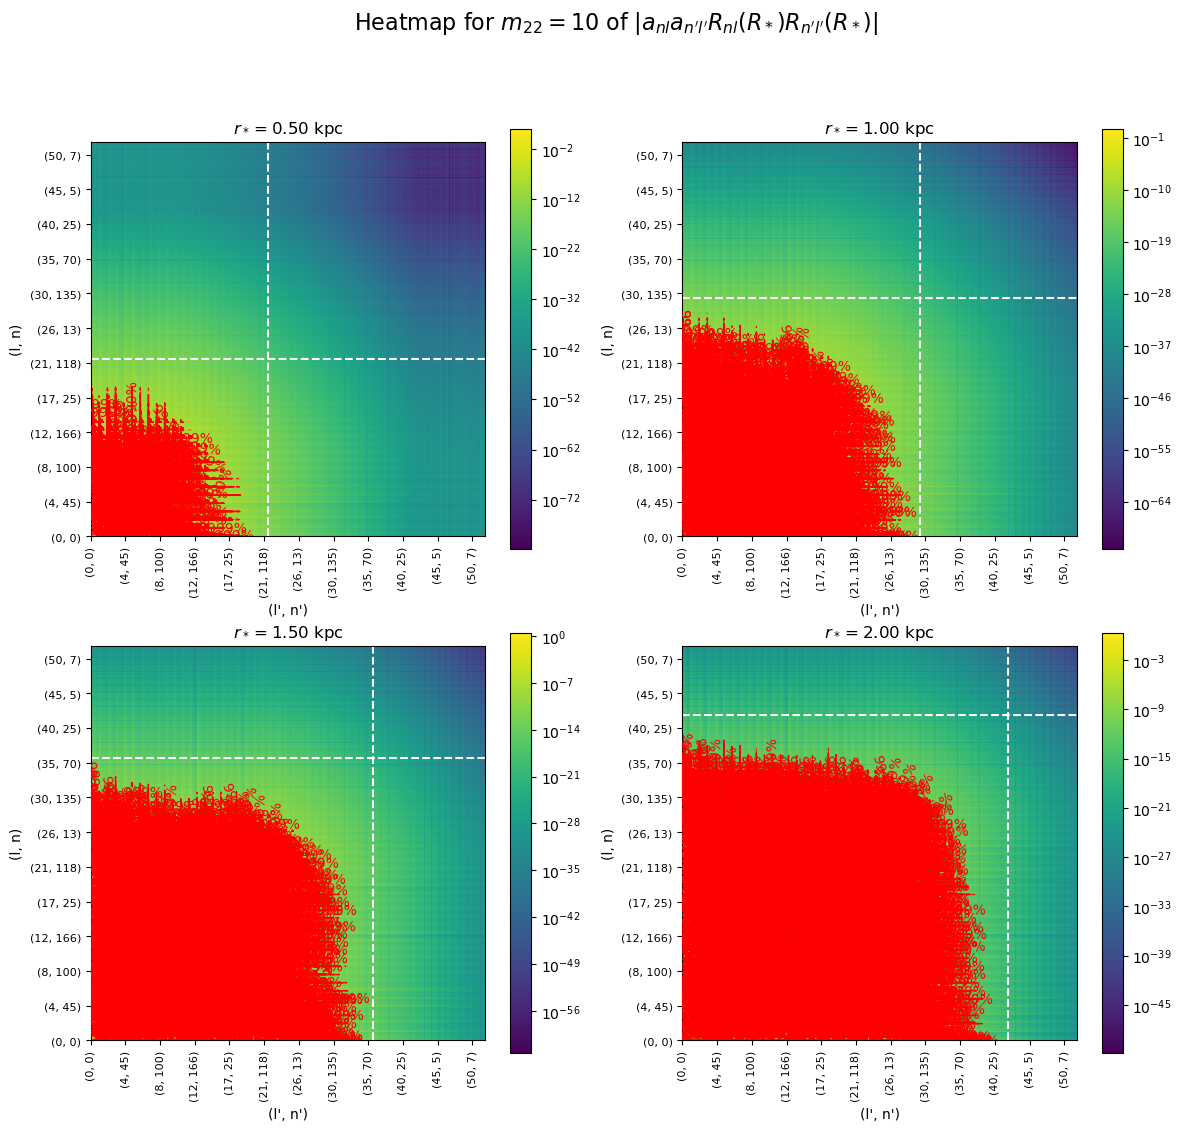

In [49]:
r_star = np.array([0.5, 1, 1.5, 2]) * u.from_Kpc

print(aj.shape)
print(R_j_r.shape)

#evaluate R at r_*

r = np.logspace(jnp.log10(rmin), jnp.log10(rmax), no_radius_bins)

R_evaled = R_j_r[[np.argmin(np.abs([r - r_star])) for r_star in r_star], :]

print(R_evaled.shape)

# construct matrix for (n,l) and (n',l') pairs

l_arr = np.array(l)



# full sorted weight vector per r_star (length N, cheap)
v_full     = np.abs(aj)[None, :] * np.abs(R_evaled)  # (n_rstar, N)
true_total = (v_full.sum(axis=1))**2                                          # (n_rstar,)
   

target = 0.99999
cumv   = np.cumsum(v_full, axis=1) / v_full.sum(axis=1, keepdims=True)
K_per  = (cumv < np.sqrt(target)).sum(axis=1) + 1   # modes needed per r_star
K      = int(K_per.max())
K = int(K * 1.5)         
print(K)                

# Plot heatmap

step = max(1, len(nl_labels) // 30)          # ~30 labels
tick_positions = np.arange(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]


from matplotlib.colors import LogNorm, SymLogNorm

fig, ax = plt.subplots(2,2, figsize=(14, 12))

n_rstar = len(r_star)

for i in range(n_rstar):

    print(f"Plotting heatmap for r_star = {r_star[i] * u.to_Kpc:.2f} kpc...")
    v_i = v_full[i, :K]
    A   = np.outer(v_i, v_i)         # K×K block, no need for the full N×N matrix at all

    total   = true_total[i]           # full-matrix total, NOT A.sum()
    asc     = np.sort(A.ravel())
    cum_low = np.cumsum(asc) / total

    def level_drop_fraction(p):
        idx = np.searchsorted(cum_low, p)    # cells below here sum to p·total
        return asc[min(idx, len(asc) - 1)]

    keep    = [0.99999, 0.9999, 0.999]             # retained fraction
    levels  = [level_drop_fraction(1 - k) for k in keep]   # ascending
    label_of = {lv: k for lv, k in zip(levels, keep)}

    im = ax[i//2, i%2].imshow(A, cmap='viridis', norm=LogNorm(),
                origin='lower', aspect='equal', interpolation='nearest')

    cs = ax[i//2, i%2].contour(A, levels=levels, colors='red', linewidths=1.0)
    ax[i//2, i%2].clabel(cs, fmt=lambda v: f"{label_of[min(label_of, key=lambda L: abs(L-v))]*100:.3f}%")

    fig.colorbar(im, ax=ax[i//2, i%2])

    ax[i//2, i%2].set_xticks(tick_positions)
    ax[i//2, i%2].set_yticks(tick_positions)
    ax[i//2, i%2].set_xticklabels(tick_labels, rotation=90, fontsize=8)
    ax[i//2, i%2].set_yticklabels(tick_labels, fontsize=8)


    ax[i//2, i%2].set_title(f"$r_* = {r_star[i] * u.to_Kpc:.2f}$ kpc")
    ax[i//2, i%2].set_xlabel("(l', n')")
    ax[i//2, i%2].set_ylabel("(l, n)")

    mask = A >= levels[0]

    rows, cols = np.where(mask)

    l_max = max(l[rows].max(), l[cols].max())
    l_max_plot = l_max + 3

    l_max_plot_idx = np.argwhere(l_arr == l_max_plot)[0][0]

    ax[i//2, i%2].axhline(y=l_max_plot_idx, color='white', ls='--', linewidth=1.5)
    ax[i//2, i%2].axvline(x=l_max_plot_idx, color='white', ls='--', linewidth=1.5)

    ax[i//2, i%2].set_xlim(0, K)
    ax[i//2, i%2].set_ylim(0, K)


#plt.tight_layout()
plt.suptitle(r"Heatmap for $m_{22}$" + f"$ = {m22:.0f}$" + r" of $|a_{nl} a_{n'l'} R_{nl}(R_*) R_{n'l'}(R_*)|$", fontsize=16)
plt.show()

Plotting heatmap for r_star = 0.50 kpc...
Plotting heatmap for r_star = 1.00 kpc...
Plotting heatmap for r_star = 1.50 kpc...
Plotting heatmap for r_star = 2.00 kpc...


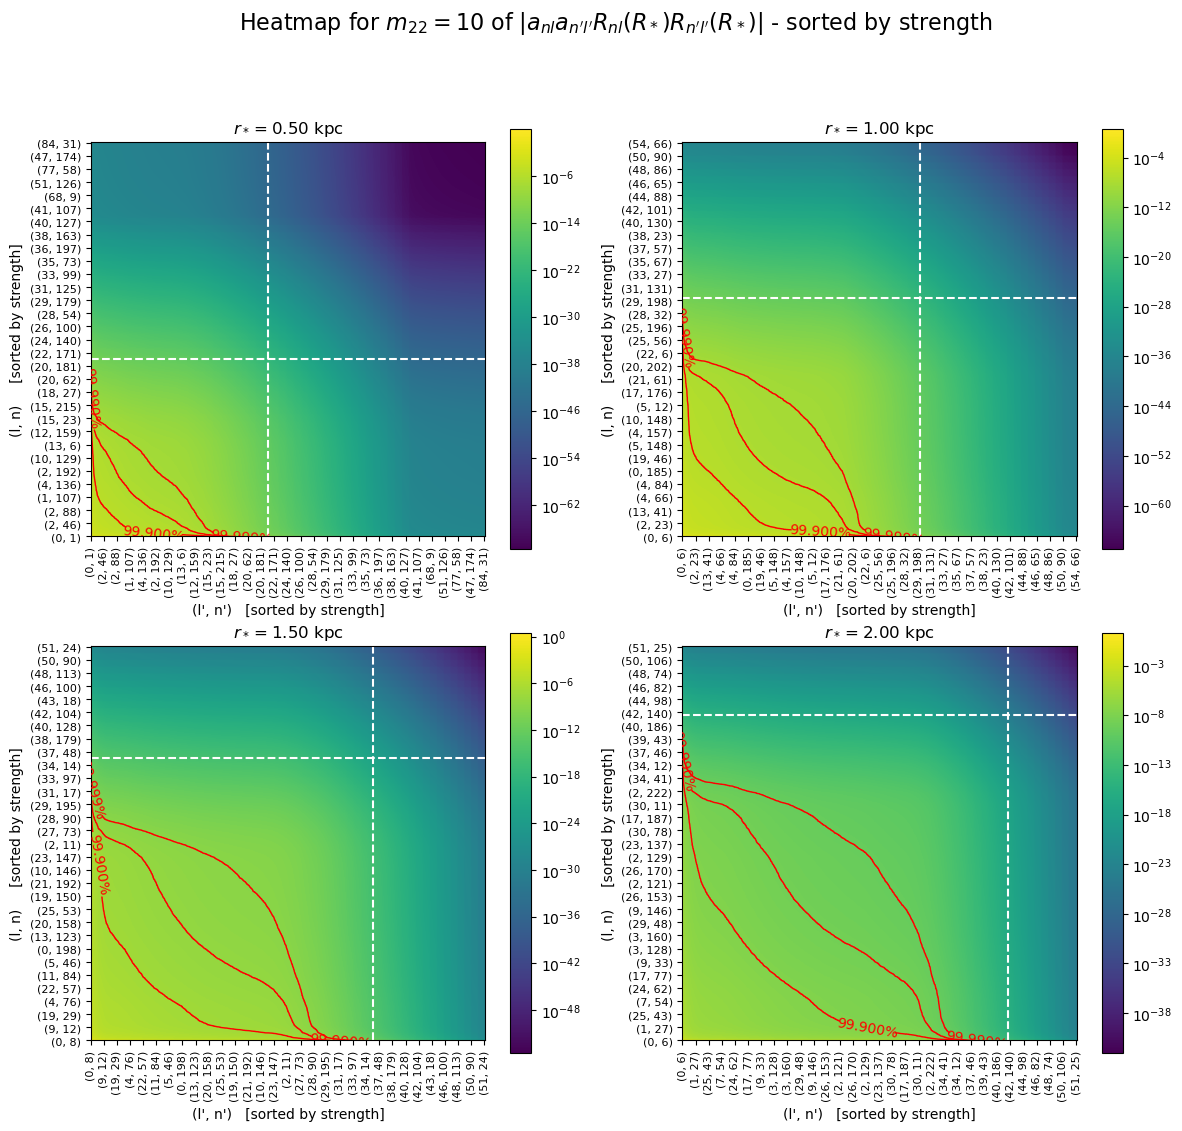

In [50]:
# Plot heatmap - sorted by strength

step = max(1, len(nl_labels) // 30)          # ~30 labels
tick_positions = np.arange(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]


from matplotlib.colors import LogNorm, SymLogNorm

fig, ax = plt.subplots(2,2, figsize=(14, 12))

n_rstar = len(r_star)

for i in range(n_rstar):

    print(f"Plotting heatmap for r_star = {r_star[i] * u.to_Kpc:.2f} kpc...")
    top = np.argsort(v_full[i])[::-1][:K]   # strongest K modes first
    v_i = v_full[i, top]
    A   = np.outer(v_i, v_i)         # K×K block, no need for the full N×N matrix at all

    labels_sorted = [nl_labels[j] for j in top]

    total   = true_total[i]           # full-matrix total, NOT A.sum()
    asc     = np.sort(A.ravel())
    cum_low = np.cumsum(asc) / total

    def level_drop_fraction(p):
        idx = np.searchsorted(cum_low, p)    # cells below here sum to p·total
        return asc[min(idx, len(asc) - 1)]

    keep    = [0.99999, 0.9999, 0.999]             # retained fraction
    levels  = [level_drop_fraction(1 - k) for k in keep]   # ascending
    label_of = {lv: k for lv, k in zip(levels, keep)}

    im = ax[i//2, i%2].imshow(A, cmap='viridis', norm=LogNorm(),
                origin='lower', aspect='equal', interpolation='nearest')

    cs = ax[i//2, i%2].contour(A, levels=levels, colors='red', linewidths=1.0)
    ax[i//2, i%2].clabel(cs, fmt=lambda v: f"{label_of[min(label_of, key=lambda L: abs(L-v))]*100:.3f}%")

    fig.colorbar(im, ax=ax[i//2, i%2])

    # ticks in the new (strength-sorted) order
    step_s          = max(1, len(labels_sorted) // 30)
    tick_positions_s = np.arange(0, len(labels_sorted), step_s)
    tick_labels_s    = [labels_sorted[j] for j in tick_positions_s]
    ax[i//2, i%2].set_xticks(tick_positions_s)
    ax[i//2, i%2].set_yticks(tick_positions_s)
    ax[i//2, i%2].set_xticklabels(tick_labels_s, rotation=90, fontsize=8)
    ax[i//2, i%2].set_yticklabels(tick_labels_s, fontsize=8)


    ax[i//2, i%2].set_title(f"$r_* = {r_star[i] * u.to_Kpc:.2f}$ kpc")
    ax[i//2, i%2].set_xlabel("(l', n')   [sorted by strength]")
    ax[i//2, i%2].set_ylabel("(l, n)     [sorted by strength]")

    mask = A >= levels[0]

    rows, cols = np.where(mask)

    l_max = max(l[top[rows]].max(), l[top[cols]].max())
    l_max_plot = l_max + 3

    l_max_plot_idx = np.argwhere(l_arr == l_max_plot)[0][0]

    ax[i//2, i%2].axhline(y=l_max_plot_idx, color='white', ls='--', linewidth=1.5)
    ax[i//2, i%2].axvline(x=l_max_plot_idx, color='white', ls='--', linewidth=1.5)

    ax[i//2, i%2].set_xlim(0, K)
    ax[i//2, i%2].set_ylim(0, K)


#plt.tight_layout()
plt.suptitle(r"Heatmap for $m_{22}$" + f"$ = {m22:.0f}$" + r" of $|a_{nl} a_{n'l'} R_{nl}(R_*) R_{n'l'}(R_*)|$ - sorted by strength", fontsize=16)
plt.show()

## Heat map for the time scale of oscillations for $dt$ restriction

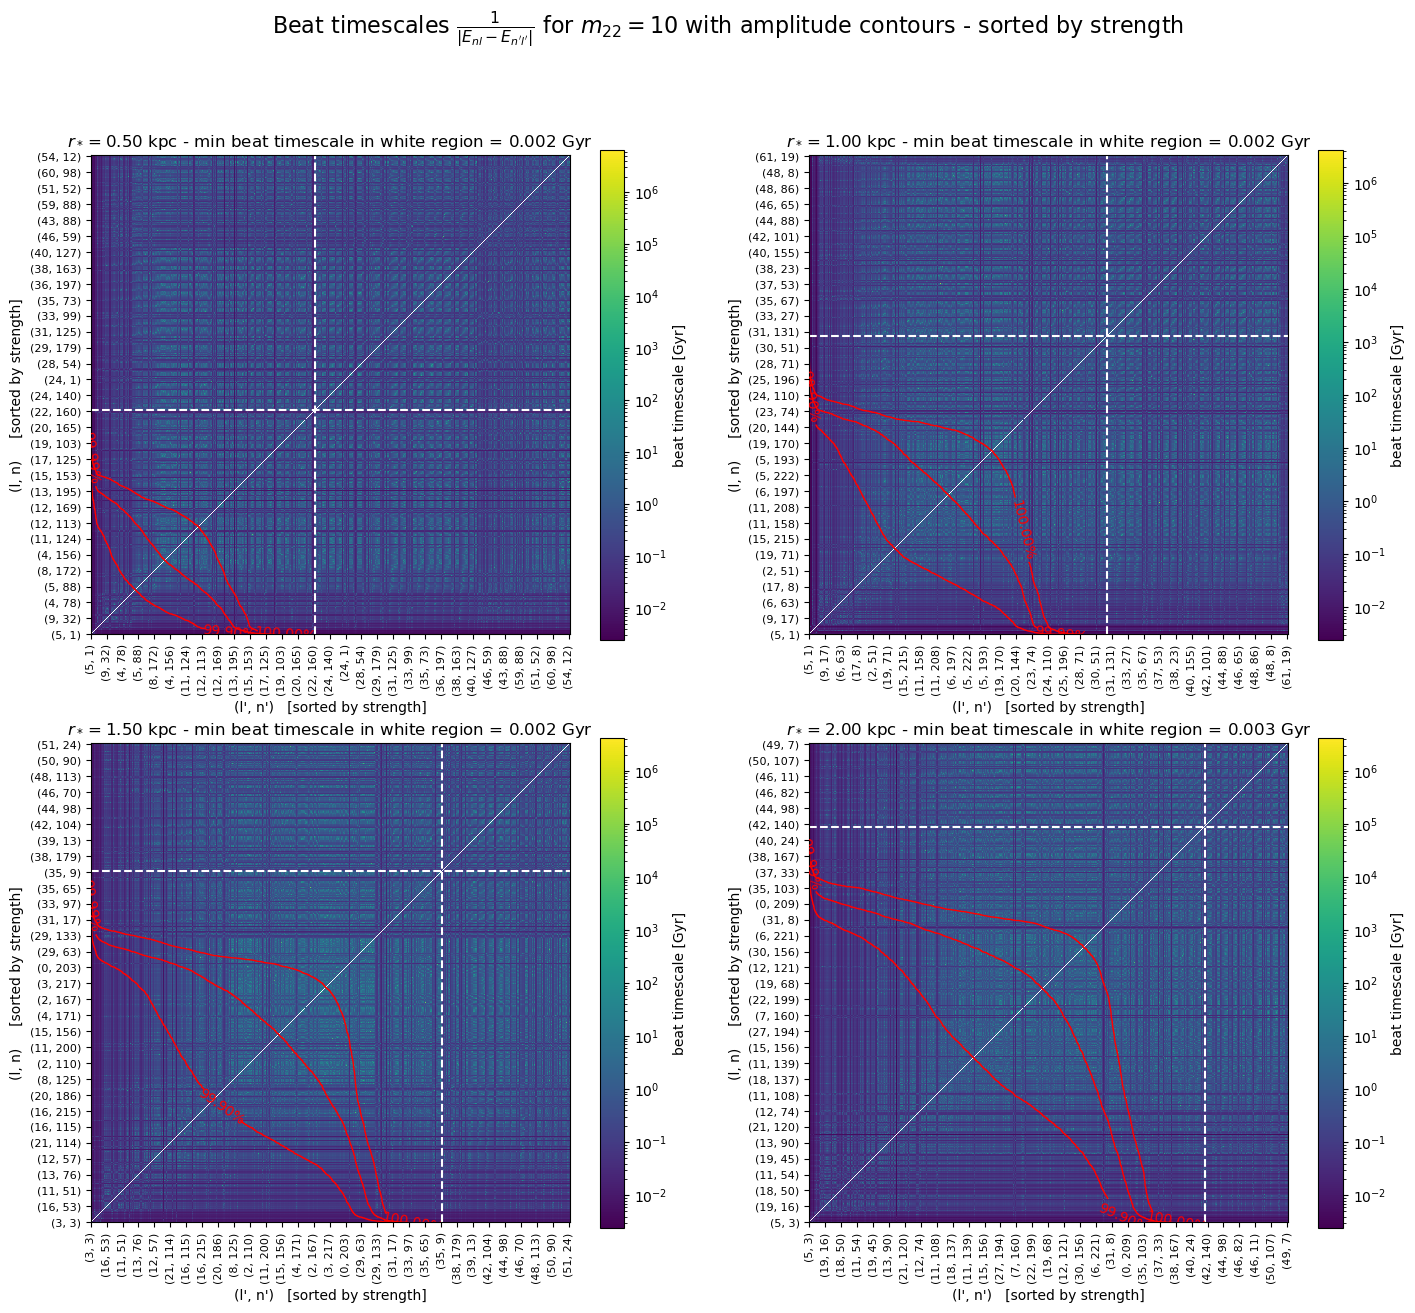

In [51]:
E_nl = eigen_energies

# --- red contours: the SAME amplitude field used in the heatmaps above ---
# pick which r_* slice the dominant-pair contours come from (0 -> 0.5 kpc, ... 3 -> 2 kpc)

# Plot heatmap - sorted by strength
step = max(1, len(nl_labels) // 30)          # ~30 labels
tick_positions = np.arange(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]

from matplotlib.colors import LogNorm, SymLogNorm

fig, ax = plt.subplots(2,2, figsize=(17, 14))


for i_star in range(len(r_star)):

    print(f"Plotting beat timescale heatmap for r_star = {r_star[i_star] * u.to_Kpc:.2f} kpc...")

    # per-mode amplitude (the diagonal sqrt of the amplitude field)
    u_amp = np.abs(
        aj * (2*l + 1) * R_evaled[i_star]
    ) * np.sqrt(float(u.to_Msun / u.to_Kpc**3))

    top = np.argsort(u_amp)[::-1][:K]          # strongest K modes first
    A_amp = np.outer(u_amp[top], u_amp[top])   # K×K amplitude block

    # matching beat-timescale block, built only for the kept modes
    E_top  = np.asarray(E_nl)[top]
    A_time = np.abs(1.0 / (E_top[:, None] - E_top[None, :]) * u.to_Gyr)

    labels_sorted = [nl_labels[j] for j in top]

    # retained-fraction contour levels computed from the amplitude field (same recipe as before)
    total   = u_amp.sum()**2          # full-matrix total, NOT A_amp.sum()
    asc     = np.sort(A_amp.ravel())
    cum_low = np.cumsum(asc) / total

    def level_drop_fraction(p):
        idx = np.searchsorted(cum_low, p)
        return asc[min(idx, len(asc) - 1)]


    levels   = [level_drop_fraction(1 - k) for k in keep]  # ascending amplitude thresholds
    label_of = {lv: k for lv, k in zip(levels, keep)}


    im = ax[i_star // 2, i_star % 2].imshow(A_time, cmap='viridis', norm=LogNorm(),
                origin='lower', aspect='equal', interpolation='nearest')

    # red lines = amplitude contours from the plots above, overlaid on the timescale map
    cs = ax[i_star // 2, i_star % 2].contour(A_amp, levels=levels, colors='red', linewidths=1.0)
    ax[i_star // 2, i_star % 2].clabel(cs, fmt=lambda v: f"{label_of[min(label_of, key=lambda L: abs(L-v))]*100:.2f}%")

    fig.colorbar(im, ax=ax[i_star // 2, i_star % 2], label=r'beat timescale [Gyr]')

    # ticks in the new (strength-sorted) order
    step_s           = max(1, len(labels_sorted) // 30)
    tick_positions_s = np.arange(0, len(labels_sorted), step_s)
    tick_labels_s    = [labels_sorted[j] for j in tick_positions_s]
    ax[i_star // 2, i_star % 2].set_xticks(tick_positions_s)
    ax[i_star // 2, i_star % 2].set_yticks(tick_positions_s)
    ax[i_star // 2, i_star % 2].set_xticklabels(tick_labels_s, rotation=90, fontsize=8)
    ax[i_star // 2, i_star % 2].set_yticklabels(tick_labels_s, fontsize=8)

    ax[i_star // 2, i_star % 2].set_xlabel("(l', n')   [sorted by strength]")
    ax[i_star // 2, i_star % 2].set_ylabel("(l, n)     [sorted by strength]")

    mask = A_amp >= levels[0]

    rows, cols = np.where(mask)

    l_max = max(l[top[rows]].max(), l[top[cols]].max())
    l_max_plot = l_max + 3

    l_max_plot_idx = np.argwhere(l_arr == l_max_plot)[0][0]

    ax[i_star // 2, i_star % 2].axhline(y=l_max_plot_idx, color='white', ls='--', linewidth=1.5)
    ax[i_star // 2, i_star % 2].axvline(x=l_max_plot_idx, color='white', ls='--', linewidth=1.5)

    min_t_in_allowed = A_time[mask].min()

    ax[i_star // 2, i_star % 2].set_title(f"$r_* = {r_star[i_star] * u.to_Kpc:.2f}$ kpc - min beat timescale in white region = {min_t_in_allowed:.3f} Gyr")

    ax[i_star // 2, i_star % 2].set_xlim(0, K)
    ax[i_star // 2, i_star % 2].set_ylim(0, K)



#plt.tight_layout()
plt.suptitle(r"Beat timescales $\frac{1}{|E_{nl}-E_{n^\prime l^\prime}|}$ for $m_{22}$" + f"$ = {m22:.0f}$" + r" with amplitude contours - sorted by strength", fontsize=16)
plt.show()